In [1]:
#pip install pandas
#%pip install seaborn

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("gender_classification_v7.csv")
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [4]:
df["gender"].value_counts() 

gender
Female    2501
Male      2500
Name: count, dtype: int64

In [5]:
df.shape

(5001, 8)

In [6]:
df.isna().sum()

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1768)

In [8]:
df[df.duplicated()]

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
59,1,14.1,5.9,0,0,0,0,Female
66,1,14.2,6.2,0,0,0,0,Female
175,1,12.7,5.7,1,1,1,1,Male
230,1,12.9,5.1,0,0,0,0,Female
261,1,13.0,6.2,1,1,1,1,Male
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [9]:
# code from ai
# This shows every copy AND the original, sorted so you can compare them side-by-side
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
374,0,11.4,5.4,0,0,0,0,Female
692,0,11.4,5.4,0,0,0,0,Female
2612,0,11.4,5.4,0,0,0,0,Female
4247,0,11.4,5.8,0,0,0,0,Female
4341,0,11.4,5.8,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
1036,1,15.5,6.8,1,1,1,1,Male
1787,1,15.5,7.0,1,1,1,1,Male
4734,1,15.5,7.0,1,1,1,1,Male
1324,1,15.5,7.1,1,1,1,1,Male


In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(3233, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 3233 entries, 0 to 4995
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  3233 non-null   int64  
 1   forehead_width_cm          3233 non-null   float64
 2   forehead_height_cm         3233 non-null   float64
 3   nose_wide                  3233 non-null   int64  
 4   nose_long                  3233 non-null   int64  
 5   lips_thin                  3233 non-null   int64  
 6   distance_nose_to_lip_long  3233 non-null   int64  
 7   gender                     3233 non-null   str    
dtypes: float64(2), int64(5), str(1)
memory usage: 227.3 KB


In [13]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000
mean,0.822456,13.217198,5.966038,0.536344,0.557686,0.538509,0.545314
std,0.382188,1.115993,0.549789,0.498755,0.496738,0.498592,0.498019
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.300000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.200000,5.900000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,14.100000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [14]:
df["gender"] = df["gender"].replace(["Male", "Female"], [1,0])

In [15]:
df.corr()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
long_hair,1.000000,-0.013151,-0.005145,0.024123,0.042556,0.037514,-0.011362,0.013933
forehead_width_cm,-0.013151,1.000000,0.079665,0.212223,0.212032,0.220566,0.206636,0.323520
forehead_height_cm,-0.005145,0.079665,1.000000,0.180526,0.153438,0.170018,0.183036,0.266843
nose_wide,0.024123,0.212223,0.180526,1.000000,0.394605,0.379767,0.395401,0.661864
nose_long,0.042556,0.212032,0.153438,0.394605,1.000000,0.384860,0.377462,0.638187
lips_thin,0.037514,0.220566,0.170018,0.379767,0.384860,1.000000,0.380805,0.631065
distance_nose_to_lip_long,-0.011362,0.206636,0.183036,0.395401,0.377462,0.380805,1.000000,0.646612
gender,0.013933,0.323520,0.266843,0.661864,0.638187,0.631065,0.646612,1.000000


<Axes: >

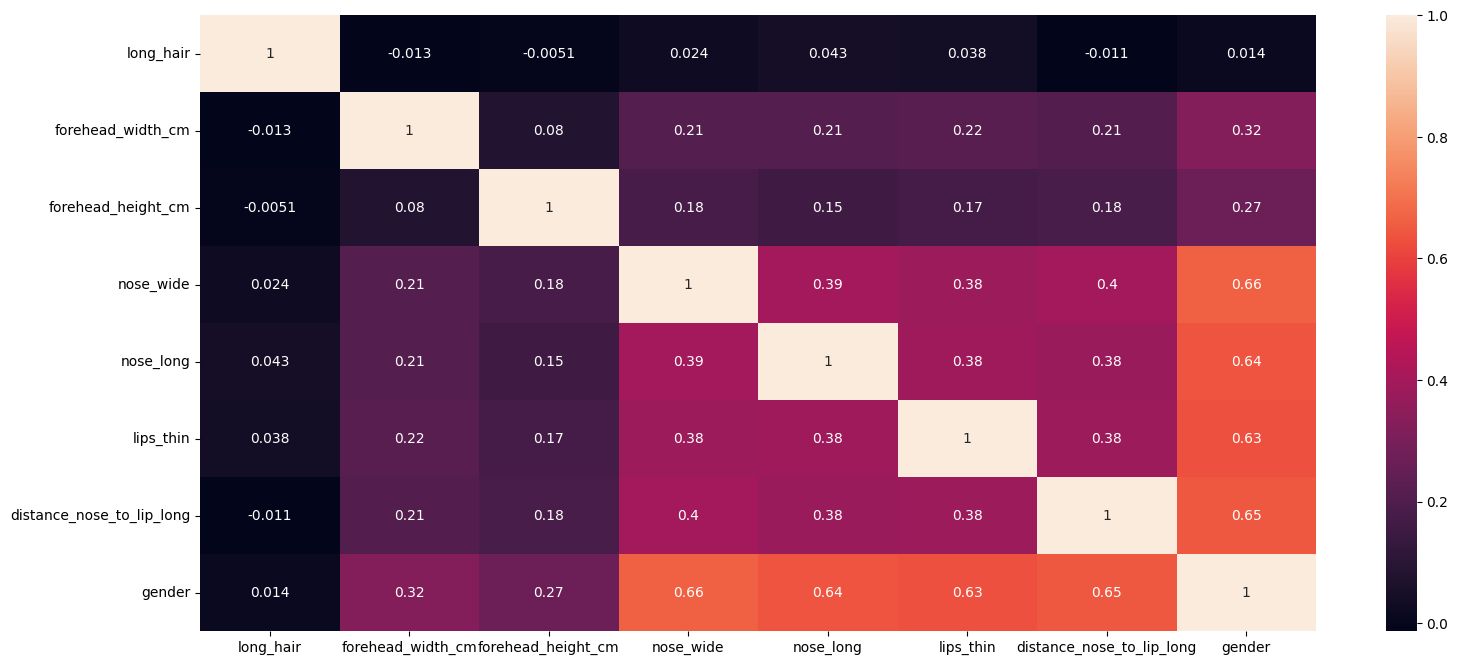

In [20]:
plt.figure(figsize=(18,8))   
sns.heatmap(df.corr(), annot = True)

<Axes: xlabel='gender'>

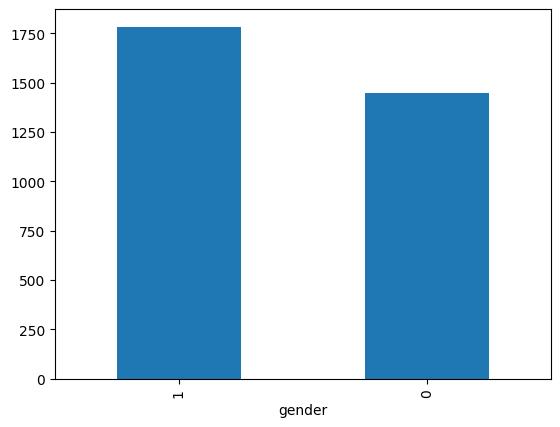

In [23]:
df["gender"].value_counts().plot(kind="bar")

In [24]:
df.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long', 'gender'],
      dtype='str')

<Axes: xlabel='gender,lips_thin'>

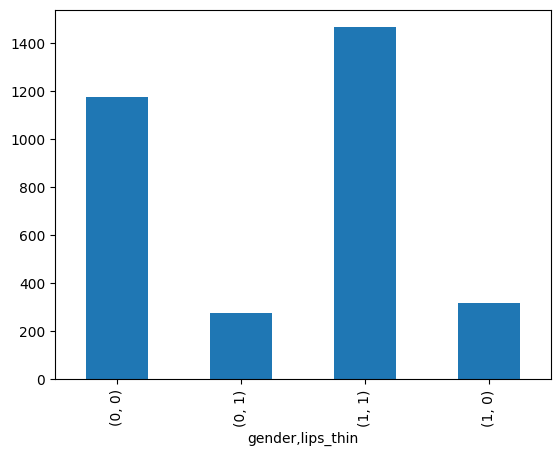

In [28]:
df.groupby("gender")["lips_thin"].value_counts().plot(kind= "bar")